In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [3]:
def price_barrier_option(option_type, ticker, K, barrier_price):
    # Descargar precios históricos
    data = yf.download(ticker, start='2022-01-01', end='2025-03-15')['Close']['SPY']
    daily_returns = data.pct_change().dropna()

    # Parámetros
    S0 = float(data.iloc[-1])
    sigma = daily_returns.std() * np.sqrt(252)
    r = 0.10
    T_days = 252
    T = 1  # años
    dt = T / T_days
    num_simulations = 10000
    Z = np.random.normal(0, 1, (num_simulations, T_days))

    returns = (r - 0.5 * sigma**2) * dt  +  sigma * np.sqrt(dt) * Z
    prices = S0 * np.cumprod(1 + returns, axis=1)

    ST = prices[:, -1]

    barrier_breached = np.any(prices >= barrier_price, axis=1)

    if option_type == 'call':

        payoff_barrier = np.where(~barrier_breached, np.maximum(ST - K, 0), 0 )

        # Payoff opcion sin barrera
        payoff_plain = np.maximum(ST - K, 0)

    elif option_type == 'put':

        payoff_barrier = np.where(~barrier_breached, np.maximum(K - ST, 0), 0 )
        # Payoff opcion sin barrera
        payoff_plain = np.maximum(K - ST, 0)

    price_barrier = np.exp(-r * T) * np.mean(payoff_barrier)
    price_normal = np.exp(-r * T) * np.mean(payoff_plain)
    price_difference = price_normal - price_barrier

    return {
        'S0': S0
        ,'price_plain': price_normal
        ,'price_barrier': price_barrier
        ,'price_difference': price_difference
        }



In [4]:
price_barrier_option( 'put', 'SPY', 620, 621)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


{'S0': 561.1220092773438,
 'price_plain': np.float64(43.97618793101015),
 'price_barrier': np.float64(32.733721924352395),
 'price_difference': np.float64(11.242466006657757)}

### Actividad

1. Con K y option_type fijo, para barrier price desde 1`*`K  hasta 1.2`*`K. Grafica el precio de las opciones con y sin barrera.

2. Compara el tiempo de cómputo para 1M de simulaciones entre la opción vectorizada y no vectorizada

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

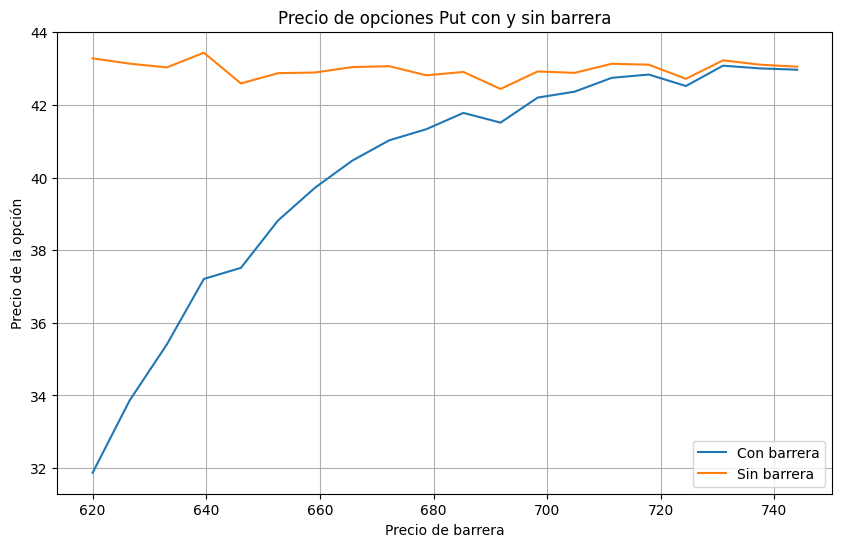

In [5]:

def price_barrier_option(option_type, ticker, K, barrier_price):
    # Descargar precios históricos
    data = yf.download(ticker, start='2022-01-01', end='2025-03-15')['Close']['SPY']
    daily_returns = data.pct_change().dropna()

    # Parámetros
    S0 = float(data.iloc[-1])
    sigma = daily_returns.std() * np.sqrt(252)
    r = 0.10
    T_days = 252
    T = 1  # años
    dt = T / T_days
    num_simulations = 100000
    Z = np.random.normal(0, 1, (num_simulations, T_days))

    returns = (r - 0.5 * sigma**2) * dt  +  sigma * np.sqrt(dt) * Z
    prices = S0 * np.cumprod(1 + returns, axis=1)

    ST = prices[:, -1]

    barrier_breached = np.any(prices >= barrier_price, axis=1)

    if option_type == 'call':
        payoff_barrier = np.where(~barrier_breached, np.maximum(ST - K, 0), 0 )
        payoff_plain = np.maximum(ST - K, 0)
    elif option_type == 'put':
        payoff_barrier = np.where(~barrier_breached, np.maximum(K - ST, 0), 0 )
        payoff_plain = np.maximum(K - ST, 0)

    price_barrier = np.exp(-r * T) * np.mean(payoff_barrier)
    price_normal = np.exp(-r * T) * np.mean(payoff_plain)
    price_difference = price_normal - price_barrier

    return {
        'S0': S0
        ,'price_plain': price_normal
        ,'price_barrier': price_barrier
        ,'price_difference': price_difference
        }

# Parámetros fijos
K = 620
option_type = 'put'
barrier_prices = np.linspace(1 * K, 1.2 * K, 20)

# Almacenar los precios
prices_barrier = []
prices_plain = []

# Calcular los precios para cada barrier price
for barrier_price in barrier_prices:
  result = price_barrier_option(option_type, 'SPY', K, barrier_price)
  prices_barrier.append(result['price_barrier'])
  prices_plain.append(result['price_plain'])

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(barrier_prices, prices_barrier, label='Con barrera')
plt.plot(barrier_prices, prices_plain, label='Sin barrera')
plt.xlabel('Precio de barrera')
plt.ylabel('Precio de la opción')
plt.title('Precio de opciones Put con y sin barrera')
plt.legend()
plt.grid(True)
plt.show()


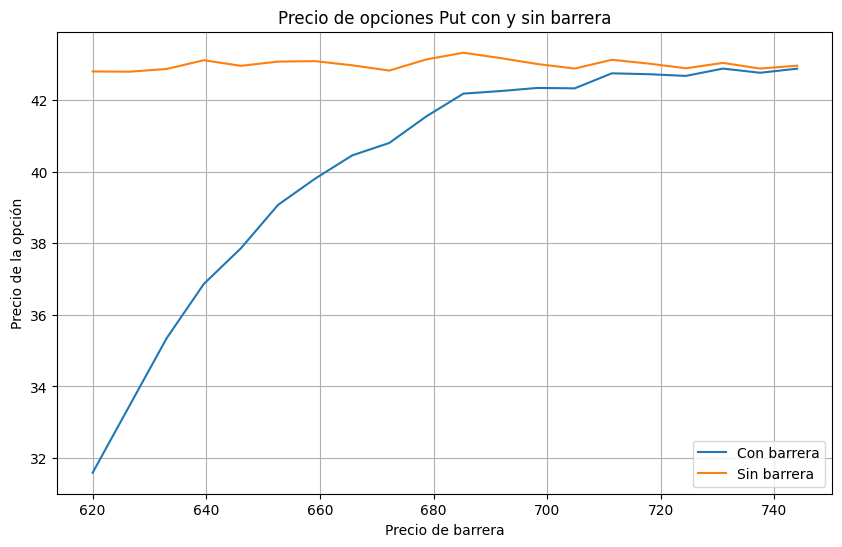

In [10]:
def price_barrier_option_no_vectorized(option_type, ticker, K, barrier_price):
    # Descargar precios históricos
    data = yf.download(ticker, start='2022-01-01', end='2025-03-15')['Close']['SPY']
    daily_returns = data.pct_change().dropna()

    # Parámetros
    S0 = float(data.iloc[-1])
    sigma = daily_returns.std() * np.sqrt(252)
    r = 0.10
    T_days = 252
    T = 1
    dt = T / T_days
    num_simulations = 100000

    price_barrier_list = []
    price_plain_list = []

    for i in range(num_simulations):
        prices = [S0]
        Z = np.random.normal(0, 1, T_days)
        barrier_breached = False

        for j in range(T_days):
            returns = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[j]
            price = prices[-1] * (1 + returns)
            prices.append(price)
            if price >= barrier_price:
                barrier_breached = True
                break

        ST = prices[-1]

        if option_type == 'call':
            if not barrier_breached:
                payoff_barrier = max(ST - K, 0)
            else:
                payoff_barrier = 0
            payoff_plain = max(ST - K, 0)
        elif option_type == 'put':
            if not barrier_breached:
                payoff_barrier = max(K - ST, 0)
            else:
                payoff_barrier = 0
            payoff_plain = max(K - ST, 0)

        price_barrier_list.append(payoff_barrier)
        price_plain_list.append(payoff_plain)

    price_barrier = np.exp(-r * T) * np.mean(price_barrier_list)
    price_normal = np.exp(-r * T) * np.mean(price_plain_list)
    price_difference = price_normal - price_barrier

    return {
        'S0': S0,
        'price_plain': price_normal,
        'price_barrier': price_barrier,
        'price_difference': price_difference
    }

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(barrier_prices, prices_barrier, label='Con barrera')
plt.plot(barrier_prices, prices_plain, label='Sin barrera')
plt.xlabel('Precio de barrera')
plt.ylabel('Precio de la opción')
plt.title('Precio de opciones Put con y sin barrera')
plt.legend()
plt.grid(True)
plt.show()



In [11]:
import time


# vectorizada
start_time = time.time()
price_barrier_option('put', 'SPY', 620, 621)
end_time = time.time()
vectorized_time = end_time - start_time
print(f"Vectorized execution time: {vectorized_time:.4f} seconds")

# no vectorizada
start_time = time.time()
price_barrier_option_no_vectorized('put', 'SPY', 620, 621)
end_time = time.time()
non_vectorized_time = end_time - start_time
print(f"Non-vectorized execution time: {non_vectorized_time:.4f} seconds")

print(f"Speedup: {non_vectorized_time / vectorized_time:.2f}x")


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Vectorized execution time: 1.6328 seconds


Non-vectorized execution time: 33.6715 seconds
Speedup: 20.62x
